Audit des données brutes

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 2018_Fixed_Leakages_Report.txt to 2018_Fixed_Leakages_Report (1).txt
Saving 2018_Leakages.csv to 2018_Leakages (1).csv
Saving 2018_SCADA.xlsx to 2018_SCADA (1).xlsx
Saving powerconsumption.csv to powerconsumption (1).csv


In [ ]:
import pandas as pd

# Electricité
elec = pd.read_csv("powerconsumption.csv")
print(elec.shape)
print(elec.head())
print(elec.info())

# Eau - SCADA
water = pd.read_excel("2018_SCADA.xlsx")
print(water.shape)
print(water.head())

# Eau - rapport de fuites (texte, fin uniquement)
with open("2018_Fixed_Leakages_Report.txt") as f:
    print(f.read()[:1000])

# Eau - fuites détaillées (CSV, début + fin)
leaks = pd.read_csv("2018_Leakages.csv", sep=";", low_memory=False)
print(leaks.iloc[:, 1:].sum())


(52416, 9)
        Datetime  Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
0  1/1/2017 0:00        6.559      73.8      0.083                0.051   
1  1/1/2017 0:10        6.414      74.5      0.083                0.070   
2  1/1/2017 0:20        6.313      74.5      0.080                0.062   
3  1/1/2017 0:30        6.121      75.0      0.083                0.091   
4  1/1/2017 0:40        5.921      75.7      0.081                0.048   

   DiffuseFlows  PowerConsumption_Zone1  PowerConsumption_Zone2  \
0         0.119             34055.69620             16128.87538   
1         0.085             29814.68354             19375.07599   
2         0.100             29128.10127             19006.68693   
3         0.096             28228.86076             18361.09422   
4         0.085             27335.69620             17872.34043   

   PowerConsumption_Zone3  
0             20240.96386  
1             20131.08434  
2             19668.43373  
3             18899.277

Résumé :
Électricité : 52 416 lignes, propre, aucune valeur manquante, 3 zones de consommation + variables météo (température, humidité, vent, flux diffus).
Eau (SCADA) : 105 120 lignes, 34 colonnes de capteurs de pression (n1, n4, n31...) à différents nœuds du réseau — pas de débit visible dans les colonnes affichées, à vérifier plus loin si présent.
Fuites : deux fichiers complémentaires —

2018_Fixed_Leakages_Report.txt : liste simple de 10 fuites réparées avec linkID + date de fin uniquement

2018_Leakages.csv : fichier détaillé et bien plus riche — label binaire (0/1) par pas de 5 minutes pour 14 conduites, permettant de connaître précisément début, fin et durée de chaque fuite. 8 conduites ont eu au moins un épisode de fuite en 2018, 5 n'en ont eu aucune.

EDA — Électricité : tendances temporelles

<Axes: xlabel='Datetime'>

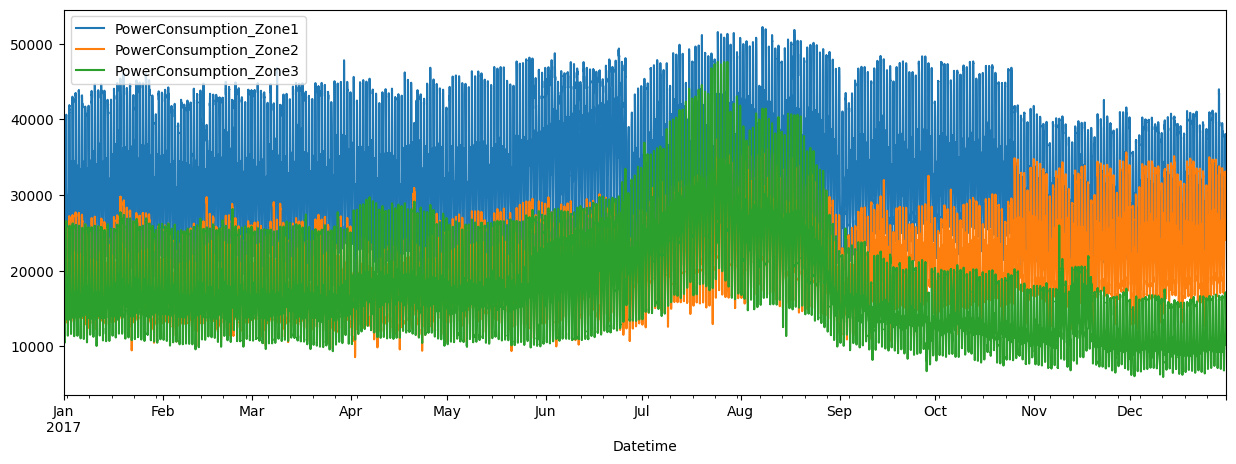

In [ ]:
import matplotlib.pyplot as plt
elec['Datetime'] = pd.to_datetime(elec['Datetime'])
elec.set_index('Datetime')[['PowerConsumption_Zone1','PowerConsumption_Zone2','PowerConsumption_Zone3']].plot(figsize=(15,5))

Zone 1 (bleu) : consommation la plus élevée toute l'année, avec un pic en été (juillet-août) — probablement lié à la climatisation
Zone 2 (orange) et Zone 3 (vert) : consommations plus faibles, avec un pattern saisonnier inversé — plus élevé en été aussi, mais montée progressive vers la fin d'année pour la Zone 2
Saisonnalité journalière bien visible (l'épaisseur "en pinceau" = cycle jour/nuit)
Pas d'anomalie flagrante, pas de trou de données

EDA eau : vérifier les valeurs manquantes du SCADA

In [ ]:
print(water.isna().sum().sum())
print(water.isna().sum()[water.isna().sum() > 0])

0
Series([], dtype: int64)


 Visualisation de la répartition des fuites dans le temps

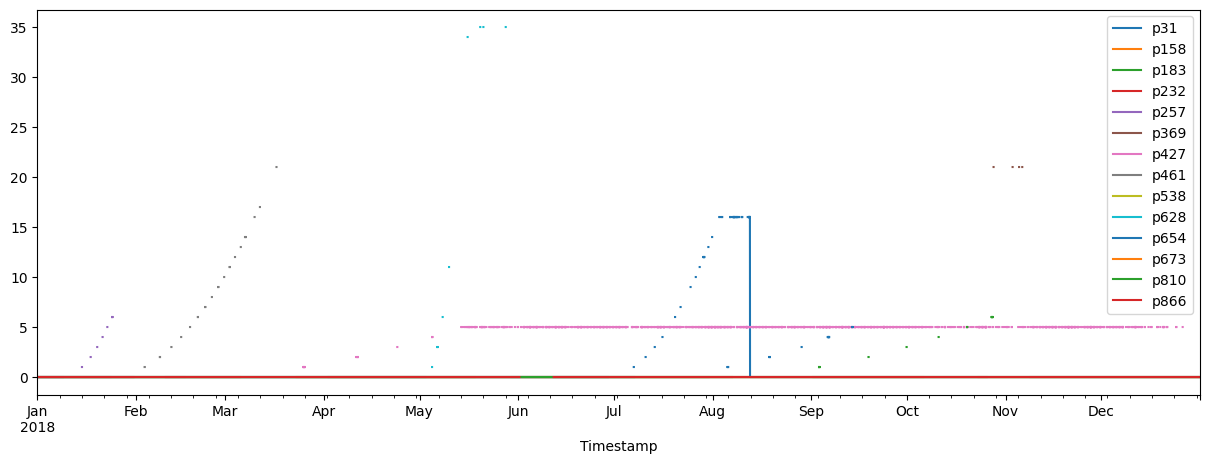

In [ ]:
leak_cols = leaks.columns[1:]
leaks[leak_cols] = leaks[leak_cols].apply(pd.to_numeric, errors='coerce')
leaks['Timestamp'] = pd.to_datetime(leaks['Timestamp'])

leaks.set_index('Timestamp')[leak_cols].plot(figsize=(15,5))
plt.show()

Bonne observation à faire : les valeurs ne sont pas binaires (0/1) comme je pensais, elles montent jusqu'à 35. En réalité, ce fichier encode probablement la sévérité/l'intensité de la fuite (ex: coefficient d'émission croissant), pas juste un flag présence/absence :

Certaines fuites (comme p427, en rose) apparaissent progressivement, se stabilisent puis durent longtemps → fuite "lente" qui grossit avec le temps
D'autres (comme p654, en bleu) montent en pic puis retombent brutalement à zéro → fuite "abrupte" détectée et réparée rapidement

C'est cohérent avec la méthodologie BattLeDIM qui simule ces deux types de fuites.

Vérification de la proportion de temps en fuite (binarisé)

In [ ]:
leak_binary = (leaks[leak_cols] > 0).astype(int)
print(leak_binary.sum())
print("Total lignes:", len(leaks))

p31      290
p158       0
p183       0
p232      13
p257      37
p369      25
p427    7055
p461     166
p538       0
p628      64
p654     124
p673       0
p810     129
p866       0
dtype: int64
Total lignes: 105120


Voilà les vrais chiffres de fuites actives (en nombre de pas de temps de 5 min) :

p427 est de très loin la plus touchée : 7 055 pas de temps (~24 jours cumulés)
4 conduites (p158, p183, p538, p673, p866) n'ont jamais eu de fuite en 2018 → elles seront à exclure ou à garder comme exemples "zéro incident"
Les autres ont des fuites ponctuelles, de durée variable

Référentiel de zones unifié

On va définir un mapping simple entre les entités "eau" et "électricité" pour simuler une seule plateforme Redal par zone géographique.
Mapping :
Zone RedalÉlecEau (conduites)ProfilZone AZone1p158, p183, p232, p673Zone stableZone BZone2p427, p369, p461, p538Zone à risque élevé (p427)Zone CZone3p31, p257, p628, p654, p810, p866Zone modérée

 Création du mapping de zones en code

In [ ]:
zone_mapping = {
    'p158': 'Zone A', 'p183': 'Zone A', 'p232': 'Zone A', 'p673': 'Zone A',
    'p427': 'Zone B', 'p369': 'Zone B', 'p461': 'Zone B', 'p538': 'Zone B',
    'p31': 'Zone C', 'p257': 'Zone C', 'p628': 'Zone C', 'p654': 'Zone C', 'p810': 'Zone C', 'p866': 'Zone C'
}

# Agrégation des fuites par zone (1 si au moins une conduite de la zone est en fuite)
zone_leaks = pd.DataFrame(index=leaks['Timestamp'])
for zone in ['Zone A', 'Zone B', 'Zone C']:
    cols = [c for c in zone_mapping if zone_mapping[c] == zone]
    zone_leaks[zone] = (leaks[cols] > 0).any(axis=1).astype(int).values

print(zone_leaks.sum())
print(zone_leaks.head())

Zone A      13
Zone B    7246
Zone C     644
dtype: int64
                     Zone A  Zone B  Zone C
Timestamp                                  
2018-01-01 00:00:00       0       0       0
2018-01-01 00:05:00       0       0       0
2018-01-01 00:10:00       0       0       0
2018-01-01 00:15:00       0       0       0
2018-01-01 00:20:00       0       0       0


Zone A : 13 pas de temps en fuite → très stable
Zone B : 7 246 pas de temps en fuite → zone à haut risque (dominée par p427)
Zone C : 644 pas de temps en fuite → risque modéré

faire pareil côté électricité : agréger PowerConsumption_Zone1/2/3 sous les mêmes noms Zone A/B/C pour préparer la fusion des deux sources sur un référentiel commun.

In [ ]:
elec_renamed = elec.rename(columns={
    'PowerConsumption_Zone1': 'Zone A',
    'PowerConsumption_Zone2': 'Zone B',
    'PowerConsumption_Zone3': 'Zone C'
})
print(elec_renamed.head())

             Datetime  Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
0 2017-01-01 00:00:00        6.559      73.8      0.083                0.051   
1 2017-01-01 00:10:00        6.414      74.5      0.083                0.070   
2 2017-01-01 00:20:00        6.313      74.5      0.080                0.062   
3 2017-01-01 00:30:00        6.121      75.0      0.083                0.091   
4 2017-01-01 00:40:00        5.921      75.7      0.081                0.048   

   DiffuseFlows       Zone A       Zone B       Zone C  
0         0.119  34055.69620  16128.87538  20240.96386  
1         0.085  29814.68354  19375.07599  20131.08434  
2         0.100  29128.10127  19006.68693  19668.43373  
3         0.096  28228.86076  18361.09422  18899.27711  
4         0.085  27335.69620  17872.34043  18442.40964  


 Features temporelles relatives (communes aux deux sources)

In [ ]:
# Electricité
elec_renamed['month'] = elec_renamed['Datetime'].dt.month
elec_renamed['dayofweek'] = elec_renamed['Datetime'].dt.dayofweek
elec_renamed['hour'] = elec_renamed['Datetime'].dt.hour

# Eau
zone_leaks_reset = zone_leaks.reset_index()
zone_leaks_reset['month'] = zone_leaks_reset['Timestamp'].dt.month
zone_leaks_reset['dayofweek'] = zone_leaks_reset['Timestamp'].dt.dayofweek
zone_leaks_reset['hour'] = zone_leaks_reset['Timestamp'].dt.hour

print(elec_renamed[['Datetime','month','dayofweek','hour']].head())
print(zone_leaks_reset[['Timestamp','month','dayofweek','hour']].head())

             Datetime  month  dayofweek  hour
0 2017-01-01 00:00:00      1          6     0
1 2017-01-01 00:10:00      1          6     0
2 2017-01-01 00:20:00      1          6     0
3 2017-01-01 00:30:00      1          6     0
4 2017-01-01 00:40:00      1          6     0
            Timestamp  month  dayofweek  hour
0 2018-01-01 00:00:00      1          0     0
1 2018-01-01 00:05:00      1          0     0
2 2018-01-01 00:10:00      1          0     0
3 2018-01-01 00:15:00      1          0     0
4 2018-01-01 00:20:00      1          0     0


Création des labels d'incidents électriques (détection d'anomalies)

In [ ]:
import numpy as np

for zone in ['Zone A', 'Zone B', 'Zone C']:
    mean_ = elec_renamed.groupby(['month', 'hour'])[zone].transform('mean')
    std_ = elec_renamed.groupby(['month', 'hour'])[zone].transform('std')
    z_score = (elec_renamed[zone] - mean_) / std_
    elec_renamed[f'{zone}_incident'] = (z_score.abs() > 3).astype(int)

print(elec_renamed[['Zone A_incident','Zone B_incident','Zone C_incident']].sum())

Zone A_incident    317
Zone B_incident    207
Zone C_incident    243
dtype: int64


Résultats cohérents et équilibrés :

Zone A : 317 incidents détectés
Zone B : 207 incidents détectés
Zone C : 243 incidents détectés

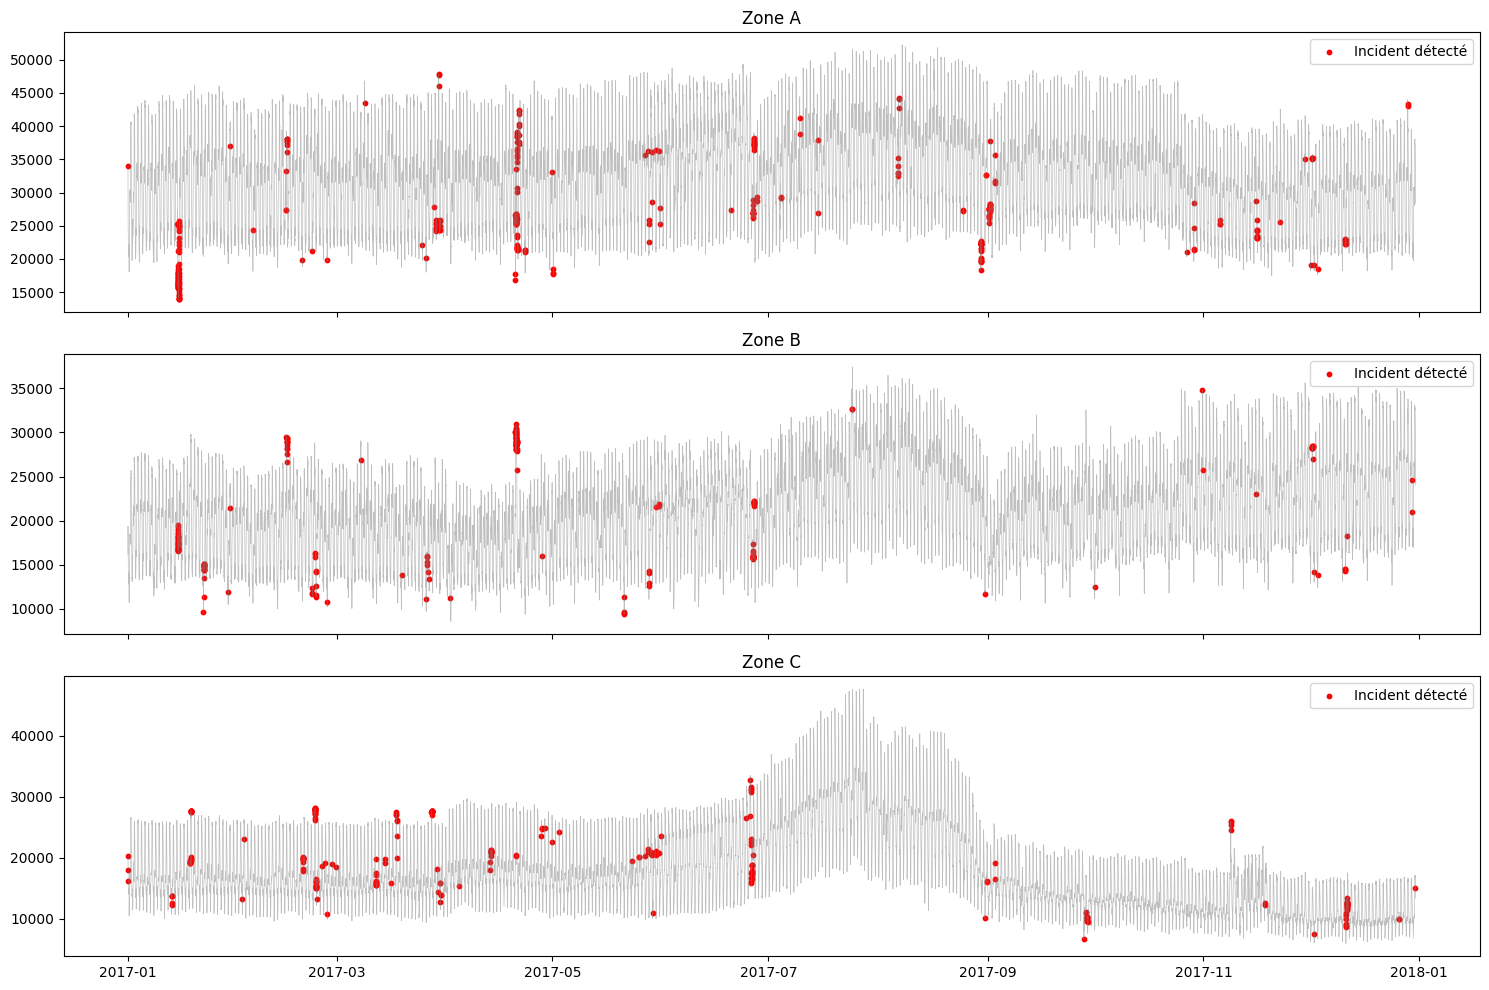

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for ax, zone in zip(axes, ['Zone A', 'Zone B', 'Zone C']):
    ax.plot(elec_renamed['Datetime'], elec_renamed[zone], color='gray', alpha=0.5, linewidth=0.5)
    incidents = elec_renamed[elec_renamed[f'{zone}_incident'] == 1]
    ax.scatter(incidents['Datetime'], incidents[zone], color='red', s=10, label='Incident détecté')
    ax.set_title(zone)
    ax.legend()

plt.tight_layout()
plt.show()

Quelques observations utiles :

Les anomalies sont réparties sur toute l'année, ce qui est bon signe (pas de biais saisonnier écrasant)
Certains clusters d'anomalies concentrées sur quelques jours (ex: Zone A début janvier, Zone A/B/C fin avril) suggèrent des événements ponctuels réels (canicule, vague de froid, jour férié atypique) — bon argument à mentionner en soutenance
Zone C montre bien sa tendance saisonnière (montée en été) et les anomalies s'ajustent correctement à cette tendance plutôt que de juste flagger tout l'été comme anormal — preuve que le modèle (groupby mois+heure) fonctionne bien

 Préparer le dataset pour la modélisation (électricité)

In [ ]:
from sklearn.model_selection import train_test_split

features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'month', 'dayofweek', 'hour']

X = elec_renamed[features]
y = elec_renamed['Zone A_incident']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(41932, 8) (10484, 8)
Zone A_incident
0    41678
1      254
Name: count, dtype: int64


 Isolation Forest (détection d'anomalies non supervisée)

In [ ]:
from sklearn.ensemble import IsolationForest

features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'Zone A', 'month', 'dayofweek', 'hour']

X = elec_renamed[features]

iso = IsolationForest(n_estimators=200, contamination=0.006, random_state=42)
iso_pred = iso.fit_predict(X)

# iso_pred donne -1 pour anomalie, 1 pour normal -> on convertit en 0/1
elec_renamed['iso_incident'] = (iso_pred == -1).astype(int)

print(elec_renamed['iso_incident'].sum())
print(elec_renamed[['iso_incident', 'Zone A_incident']].corr())

315
                 iso_incident  Zone A_incident
iso_incident         1.000000        -0.002881
Zone A_incident     -0.002881         1.000000


Visualisation des anomalies Isolation Forest dans le temps

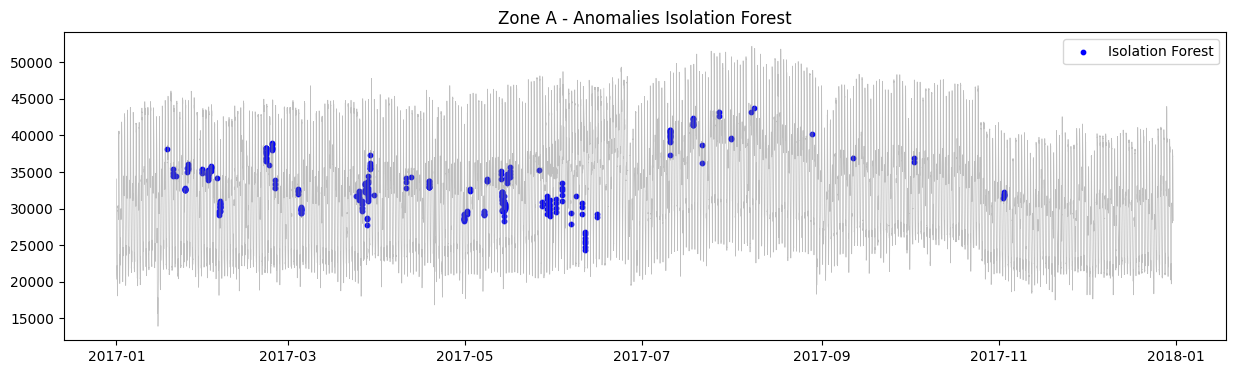

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(elec_renamed['Datetime'], elec_renamed['Zone A'], color='gray', alpha=0.5, linewidth=0.5)
incidents = elec_renamed[elec_renamed['iso_incident'] == 1]
ax.scatter(incidents['Datetime'], incidents['Zone A'], color='blue', s=10, label='Isolation Forest')
ax.set_title('Zone A - Anomalies Isolation Forest')
ax.legend()
plt.show()

 Isolation Forest avec features contextualisées

In [ ]:
# Créer des features d'écart au comportement habituel
mean_ = elec_renamed.groupby(['month', 'hour'])['Zone A'].transform('mean')
std_ = elec_renamed.groupby(['month', 'hour'])['Zone A'].transform('std')
elec_renamed['Zone A_dev'] = (elec_renamed['Zone A'] - mean_) / std_

features_v2 = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'Zone A_dev']

X_v2 = elec_renamed[features_v2]

iso_v2 = IsolationForest(n_estimators=200, contamination=0.006, random_state=42)
iso_pred_v2 = iso_v2.fit_predict(X_v2)

elec_renamed['iso_incident_v2'] = (iso_pred_v2 == -1).astype(int)

print(elec_renamed['iso_incident_v2'].sum())
print(elec_renamed[['iso_incident_v2', 'Zone A_incident']].corr())

315
                 iso_incident_v2  Zone A_incident
iso_incident_v2         1.000000         0.003486
Zone A_incident         0.003486         1.000000


test

In [ ]:
X_v3 = elec_renamed[['Zone A_dev']]

iso_v3 = IsolationForest(n_estimators=200, contamination=0.006, random_state=42)
iso_pred_v3 = iso_v3.fit_predict(X_v3)

elec_renamed['iso_incident_v3'] = (iso_pred_v3 == -1).astype(int)

print(elec_renamed[['iso_incident_v3', 'Zone A_incident']].corr())

                 iso_incident_v3  Zone A_incident
iso_incident_v3         1.000000         0.738936
Zone A_incident         0.738936         1.000000


Autoencoder (détection d'anomalies par deep learning)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# Features pour l'autoencoder
features_ae = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'Zone A_dev']
X_ae = elec_renamed[features_ae].values

# Normalisation (indispensable pour les réseaux de neurones)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ae)

# Architecture simple : 6 -> 4 -> 2 -> 4 -> 6
autoencoder = models.Sequential([
    layers.Input(shape=(X_scaled.shape[1],)),
    layers.Dense(4, activation='relu'),
    layers.Dense(2, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(X_scaled.shape[1], activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
history = autoencoder.fit(X_scaled, X_scaled, epochs=20, batch_size=256, validation_split=0.1, verbose=1)

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0677 - val_loss: 0.7586
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9273 - val_loss: 0.6516
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7080 - val_loss: 0.4943
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5875 - val_loss: 0.4075
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5248 - val_loss: 0.3655
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5005 - val_loss: 0.3517
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4884 - val_loss: 0.3484
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4788 - val_loss: 0.3418
Epoch 9/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4679 - val_loss: 0.3397
Epoch 10/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4555 - val_loss: 0.3337
Epoch 11/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4417 - val_loss: 0.3266
Epoch 12/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Calcul d'erreur de reconstruction et détecter les anomalies

In [ ]:
# Reconstruction et erreur par ligne
X_reconstructed = autoencoder.predict(X_scaled)
reconstruction_error = np.mean((X_scaled - X_reconstructed)**2, axis=1)

elec_renamed['reconstruction_error'] = reconstruction_error

# Seuil : on garde les 0.6% avec la plus grosse erreur (cohérent avec nos autres méthodes)
threshold = np.percentile(reconstruction_error, 99.4)
elec_renamed['ae_incident'] = (reconstruction_error > threshold).astype(int)

print(elec_renamed['ae_incident'].sum())
print(elec_renamed[['ae_incident', 'Zone A_incident', 'iso_incident_v3']].corr())

1638/1638 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
315
                 ae_incident  Zone A_incident  iso_incident_v3
ae_incident         1.000000         0.114918         0.076993
Zone A_incident     0.114918         1.000000         0.738936
iso_incident_v3     0.076993         0.738936         1.000000


 Modèle prédictif avec LightGBM

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'month', 'dayofweek', 'hour']

X = elec_renamed[features]
y = elec_renamed['Zone A_incident']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LGBMClassifier(n_estimators=200, is_unbalance=True, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 254, number of negative: 41678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1309
[LightGBM] [Info] Number of data points in the train set: 41932, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006057 -> initscore=-5.100394
[LightGBM] [Info] Start training from score -5.100394
[[9808  613]
 [  30   33]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     10421
           1       0.05      0.52      0.09        63

    accuracy                           0.94     10484
   macro avg       0.52      0.73      0.53     10484
weighted avg       0.99      0.94      0.96     10484

AUC: 0.695274194506514


Ajouter des features de lag/tendance

In [ ]:
# Tri chronologique indispensable avant de créer des lags
elec_renamed = elec_renamed.sort_values('Datetime').reset_index(drop=True)

# Lags de consommation (valeurs passées) - 1h, 3h, 6h en arrière (pas de 10 min)
elec_renamed['Zone A_lag1'] = elec_renamed['Zone A'].shift(6)   # 1h avant
elec_renamed['Zone A_lag3'] = elec_renamed['Zone A'].shift(18)  # 3h avant
elec_renamed['Zone A_lag6'] = elec_renamed['Zone A'].shift(36)  # 6h avant

# Moyenne mobile (tendance récente)
elec_renamed['Zone A_rollmean_1h'] = elec_renamed['Zone A'].rolling(6).mean()
elec_renamed['Zone A_rollstd_1h'] = elec_renamed['Zone A'].rolling(6).std()

# On supprime les lignes avec NaN créées par les lags/rolling (tout début de série)
elec_lagged = elec_renamed.dropna(subset=['Zone A_lag1','Zone A_lag3','Zone A_lag6','Zone A_rollmean_1h','Zone A_rollstd_1h'])

print(elec_lagged.shape)
print(elec_lagged[['Zone A','Zone A_lag1','Zone A_lag3','Zone A_lag6','Zone A_rollmean_1h','Zone A_rollstd_1h']].head(10))

(52380, 26)
         Zone A  Zone A_lag1  Zone A_lag3  Zone A_lag6  Zone A_rollmean_1h  \
36  22219.74684  20542.78481  21107.84810  34055.69620        21086.582278   
37  21928.10127  20621.77215  20998.48101  29814.68354        21304.303798   
38  21776.20253  20627.84810  20870.88608  29128.10127        21495.696203   
39  21654.68354  20797.97468  20870.88608  28228.86076        21638.481013   
40  21466.32911  20858.73418  20597.46835  27335.69620        21739.746835   
41  20846.58228  21393.41772  20421.26582  26624.81013        21648.607595   
42  19983.79747  22219.74684  20524.55696  25998.98734        21275.949367   
43  18908.35443  21928.10127  20482.02532  25446.07595        20772.658227   
44  18167.08861  21776.20253  20530.63291  24777.72152        20171.139240   
45  18075.94937  21654.68354  20512.40506  24279.49367        19574.683545   

    Zone A_rollstd_1h  
36         622.881131  
37         655.376886  
38         581.876980  
39         470.965123  
40       

Réentraîner LightGBM avec les nouvelles features + ajustement du seuil

In [ ]:
features_v2 = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows',
               'month', 'dayofweek', 'hour',
               'Zone A_lag1', 'Zone A_lag3', 'Zone A_lag6', 'Zone A_rollmean_1h', 'Zone A_rollstd_1h']

X2 = elec_lagged[features_v2]
y2 = elec_lagged['Zone A_incident']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

model2 = LGBMClassifier(n_estimators=200, is_unbalance=True, random_state=42)
model2.fit(X_train2, y_train2)

y_proba2 = model2.predict_proba(X_test2)[:,1]

# Test de plusieurs seuils pour trouver le meilleur compromis précision/rappel
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test2, y_proba2)

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba2 > t).astype(int)
    print(f"Seuil {t} :")
    print(classification_report(y_test2, y_pred_t, zero_division=0))

print("AUC:", roc_auc_score(y_test2, y_proba2))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 253, number of negative: 41651
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2582
[LightGBM] [Info] Number of data points in the train set: 41904, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006038 -> initscore=-5.103691
[LightGBM] [Info] Start training from score -5.103691
Seuil 0.3 :
              precision    recall  f1-score   support

           0       1.00      0.76      0.86     10413
           1       0.02      0.76      0.04        63

    accuracy                           0.76     10476
   macro avg       0.51      0.76      0.45     10476
weighted avg       0.99      0.76      0.86     10476

Seuil 0.4 :
              precision    recall  f1-score   support

           0       1.0

verfiication

In [ ]:
import numpy as np
print(np.percentile(y_proba2, [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]))

[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.78997989e-290 1.00000000e+000 1.00000000e+000 1.00000000e+000
 1.00000000e+000]


Vérifions la feature importance pour comprendre ce qui domine

In [ ]:
import pandas as pd
importances = pd.Series(model2.feature_importances_, index=features_v2).sort_values(ascending=False)
print(importances)

Temperature            684
GeneralDiffuseFlows    641
DiffuseFlows           586
Zone A_lag3            573
Zone A_lag1            567
Zone A_lag6            557
Humidity               549
Zone A_rollmean_1h     502
Zone A_rollstd_1h      497
WindSpeed              353
hour                   181
month                  177
dayofweek              133
dtype: int32


Répliquer le pipeline pour Zone B et Zone C

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

results = {}

for zone in ['Zone B', 'Zone C']:
    # Lags et rolling stats
    elec_renamed[f'{zone}_lag1'] = elec_renamed[zone].shift(6)
    elec_renamed[f'{zone}_lag3'] = elec_renamed[zone].shift(18)
    elec_renamed[f'{zone}_lag6'] = elec_renamed[zone].shift(36)
    elec_renamed[f'{zone}_rollmean_1h'] = elec_renamed[zone].rolling(6).mean()
    elec_renamed[f'{zone}_rollstd_1h'] = elec_renamed[zone].rolling(6).std()

    data = elec_renamed.dropna(subset=[f'{zone}_lag1', f'{zone}_lag3', f'{zone}_lag6',
                                         f'{zone}_rollmean_1h', f'{zone}_rollstd_1h'])

    features_zone = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows',
                      'month', 'dayofweek', 'hour',
                      f'{zone}_lag1', f'{zone}_lag3', f'{zone}_lag6',
                      f'{zone}_rollmean_1h', f'{zone}_rollstd_1h']

    X = data[features_zone]
    y = data[f'{zone}_incident']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model = LGBMClassifier(n_estimators=200, is_unbalance=True, random_state=42, verbose=-1)
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba > 0.5).astype(int)

    auc = roc_auc_score(y_test, y_proba)
    results[zone] = {'model': model, 'auc': auc}

    print(f"--- {zone} ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("AUC:", auc)
    print()

--- Zone B ---
              precision    recall  f1-score   support

           0       1.00      0.38      0.55     10435
           1       0.01      0.93      0.01        41

    accuracy                           0.39     10476
   macro avg       0.50      0.66      0.28     10476
weighted avg       1.00      0.39      0.55     10476

AUC: 0.6551205488097047

--- Zone C ---
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     10428
           1       0.02      0.67      0.04        48

    accuracy                           0.83     10476
   macro avg       0.51      0.75      0.47     10476
weighted avg       0.99      0.83      0.91     10476

AUC: 0.7506712696586113



In [ ]:
print(water.columns.tolist())

['Timestamp', 'n1', 'n4', 'n31', 'n54', 'n105', 'n114', 'n163', 'n188', 'n215', 'n229', 'n288', 'n296', 'n332', 'n342', 'n410', 'n415', 'n429', 'n458', 'n469', 'n495', 'n506', 'n516', 'n519', 'n549', 'n613', 'n636', 'n644', 'n679', 'n722', 'n726', 'n740', 'n752', 'n769']


Mapping des capteurs de pression en zones

In [ ]:
sensor_cols = [c for c in water.columns if c != 'Timestamp']
print(len(sensor_cols))

# Répartition simple en 3 groupes égaux
import numpy as np
zone_names = ['Zone A', 'Zone B', 'Zone C']
sensor_zone_map = {sensor: zone_names[i % 3] for i, sensor in enumerate(sensor_cols)}

# Moyenne de pression par zone à chaque timestamp
water['Zone A_pressure'] = water[[s for s in sensor_cols if sensor_zone_map[s]=='Zone A']].mean(axis=1)
water['Zone B_pressure'] = water[[s for s in sensor_cols if sensor_zone_map[s]=='Zone B']].mean(axis=1)
water['Zone C_pressure'] = water[[s for s in sensor_cols if sensor_zone_map[s]=='Zone C']].mean(axis=1)

print(water[['Zone A_pressure','Zone B_pressure','Zone C_pressure']].describe())

33
       Zone A_pressure  Zone B_pressure  Zone C_pressure
count    105120.000000    105120.000000    105120.000000
mean         47.147937        46.549366        45.012129
std           0.493626         0.473115         0.416297
min          45.377273        44.924545        43.575455
25%          46.772727        46.188182        44.693636
50%          47.102727        46.500909        44.965455
75%          47.532727        46.920000        45.336364
max          48.172727        47.525455        45.869091


Fusionner pression + labels de fuite par zone, puis créer les features de lag


In [ ]:
water_data = water[['Timestamp', 'Zone A_pressure', 'Zone B_pressure', 'Zone C_pressure']].copy()
water_data = water_data.merge(zone_leaks_reset[['Timestamp', 'Zone A', 'Zone B', 'Zone C']], on='Timestamp')
water_data = water_data.rename(columns={'Zone A':'Zone A_leak', 'Zone B':'Zone B_leak', 'Zone C':'Zone C_leak'})

water_data = water_data.sort_values('Timestamp').reset_index(drop=True)

# Features temporelles + lags/rolling pour chaque zone
water_data['hour'] = water_data['Timestamp'].dt.hour
water_data['dayofweek'] = water_data['Timestamp'].dt.dayofweek
water_data['month'] = water_data['Timestamp'].dt.month

for zone in ['Zone A', 'Zone B', 'Zone C']:
    col = f'{zone}_pressure'
    water_data[f'{zone}_lag1'] = water_data[col].shift(12)   # 1h avant (pas de 5 min)
    water_data[f'{zone}_lag3'] = water_data[col].shift(36)   # 3h avant
    water_data[f'{zone}_rollmean_1h'] = water_data[col].rolling(12).mean()
    water_data[f'{zone}_rollstd_1h'] = water_data[col].rolling(12).std()

water_data = water_data.dropna()
print(water_data.shape)
print(water_data.head())

(105084, 22)
             Timestamp  Zone A_pressure  Zone B_pressure  Zone C_pressure  \
36 2018-01-01 03:00:00        48.137273        47.483636        45.832727   
37 2018-01-01 03:05:00        48.133636        47.481818        45.830000   
38 2018-01-01 03:10:00        48.140000        47.488182        45.838182   
39 2018-01-01 03:15:00        48.139091        47.487273        45.836364   
40 2018-01-01 03:20:00        48.139091        47.486364        45.833636   

    Zone A_leak  Zone B_leak  Zone C_leak  hour  dayofweek  month  ...  \
36            0            0            0     3          0      1  ...   
37            0            0            0     3          0      1  ...   
38            0            0            0     3          0      1  ...   
39            0            0            0     3          0      1  ...   
40            0            0            0     3          0      1  ...   

    Zone A_rollmean_1h  Zone A_rollstd_1h  Zone B_lag1  Zone B_lag3  \
36      

 Entraîner LightGBM pour prédire les fuites, zone par zone


In [ ]:
water_results = {}

for zone in ['Zone A', 'Zone B', 'Zone C']:
    features_water = ['hour', 'dayofweek', 'month',
                       f'{zone}_pressure', f'{zone}_lag1', f'{zone}_lag3',
                       f'{zone}_rollmean_1h', f'{zone}_rollstd_1h']

    X = water_data[features_water]
    y = water_data[f'{zone}_leak']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model = LGBMClassifier(n_estimators=200, is_unbalance=True, random_state=42, verbose=-1)
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba > 0.5).astype(int)

    auc = roc_auc_score(y_test, y_proba)
    water_results[zone] = {'model': model, 'auc': auc}

    print(f"--- {zone} (eau) ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("AUC:", auc)
    print()

--- Zone A (eau) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21014
           1       0.00      0.00      0.00         3

    accuracy                           1.00     21017
   macro avg       0.50      0.50      0.50     21017
weighted avg       1.00      1.00      1.00     21017

AUC: 0.4727086704102027

--- Zone B (eau) ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     19568
           1       0.66      0.96      0.78      1449

    accuracy                           0.96     21017
   macro avg       0.83      0.96      0.88     21017
weighted avg       0.97      0.96      0.97     21017

AUC: 0.9903820028135681

--- Zone C (eau) ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.85     20888
           1       0.02      0.77      0.03       129

    accuracy                           0.73     21017
   macro avg   

Construction du dataset zone-jour

In [ ]:
elec_renamed['date'] = elec_renamed['Datetime'].dt.date

daily_list = []

for zone in ['Zone A', 'Zone B', 'Zone C']:
    daily = elec_renamed.groupby('date').agg(
        conso_mean=(zone, 'mean'),
        conso_std=(zone, 'std'),
        conso_max=(zone, 'max'),
        conso_min=(zone, 'min'),
        incident_rate=(f'{zone}_incident', 'mean')
    ).reset_index()
    daily['zone'] = zone
    daily_list.append(daily)

zone_day_df = pd.concat(daily_list, ignore_index=True)
print(zone_day_df.shape)
print(zone_day_df.head())

(1092, 7)
         date    conso_mean    conso_std    conso_max    conso_min  \
0  2017-01-01  28465.232067  6864.770301  40611.64557  18045.56962   
1  2017-01-02  28869.493671  7024.636275  41851.13924  19740.75949   
2  2017-01-03  30562.447257  7251.087859  42993.41772  19989.87342   
3  2017-01-04  30689.831224  7138.971135  43485.56962  19479.49367   
4  2017-01-05  30802.911393  7294.297358  43831.89873  20737.21519   

   incident_rate    zone  
0       0.006944  Zone A  
1       0.000000  Zone A  
2       0.000000  Zone A  
3       0.000000  Zone A  
4       0.000000  Zone A  


K-Means clustering

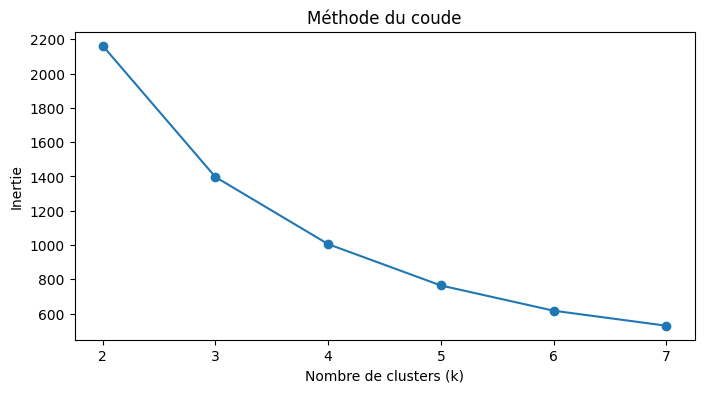

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_cluster = ['conso_mean', 'conso_std', 'conso_max', 'conso_min', 'incident_rate']

X_cluster = zone_day_df[features_cluster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Test de plusieurs k pour choisir le meilleur nombre de clusters
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,8), inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.show()

Appliquer K-Means avec k=4 et interpréter les clusters

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
zone_day_df['cluster'] = kmeans.fit_predict(X_scaled)

# Profil moyen de chaque cluster
cluster_profile = zone_day_df.groupby('cluster')[features_cluster].mean()
print(cluster_profile)

# Répartition des zones dans chaque cluster
print(pd.crosstab(zone_day_df['cluster'], zone_day_df['zone']))

           conso_mean    conso_std     conso_max     conso_min  incident_rate
cluster                                                                      
0        20317.466449  4524.555895  28693.738086  12968.599955       0.002501
1        31937.902082  6601.210623  44429.584410  21275.037192       0.001962
2        23438.519634  5444.574059  33705.723382  14826.853633       0.210317
3        13603.298100  3083.245535  19592.233208   8567.980255       0.001809
zone     Zone A  Zone B  Zone C
cluster                        
0             1     337     198
1           357       2      41
2             6       4       4
3             0      21     121


Croisement prédiction + segmentation pour prioriser les zones d'intervention

In [ ]:
# Score de risque basé sur le cluster (0 = normal, 1 = cluster à risque)
zone_day_df['risk_cluster'] = (zone_day_df['cluster'] == 2).astype(int)

# Score de priorité combiné : taux d'incident réel + appartenance au cluster à risque
zone_day_df['priority_score'] = zone_day_df['incident_rate'] * 0.7 + zone_day_df['risk_cluster'] * 0.3

# Top zones/jours prioritaires
top_priority = zone_day_df.sort_values('priority_score', ascending=False).head(15)
print(top_priority[['date', 'zone', 'conso_mean', 'incident_rate', 'cluster', 'priority_score']])

# Résumé par zone : score de priorité moyen
zone_summary = zone_day_df.groupby('zone')[['incident_rate', 'priority_score']].mean().sort_values('priority_score', ascending=False)
print(zone_summary)

            date    zone    conso_mean  incident_rate  cluster  priority_score
14    2017-01-15  Zone A  26771.518987       0.451389        2        0.615972
473   2017-04-20  Zone B  21631.491853       0.333333        2        0.533333
109   2017-04-20  Zone A  28433.240042       0.298611        2        0.509028
378   2017-01-15  Zone B  19632.624113       0.236111        2        0.465278
1072  2017-12-11  Zone C  11887.755102       0.208333        2        0.445833
540   2017-06-26  Zone B  17968.607068       0.208333        2        0.445833
904   2017-06-26  Zone C  22729.558974       0.180556        2        0.426389
243   2017-09-01  Zone A  29503.893805       0.166667        2        0.416667
176   2017-06-26  Zone A  31291.655629       0.166667        2        0.416667
241   2017-08-30  Zone A  32954.495006       0.159722        2        0.411806
745   2017-01-18  Zone C  18573.493976       0.152778        2        0.406944
110   2017-04-21  Zone A  32530.764263       0.15277

In [42]:
# 1. Données zone-jour avec clusters et scores de priorité (base principale du dashboard)
zone_day_df.to_csv('zone_day_summary.csv', index=False)

# 2. Détail électricité avec incidents prédits par zone (pour graphiques temporels)
elec_export = elec_renamed[['Datetime', 'Zone A', 'Zone B', 'Zone C',
                              'Zone A_incident', 'Zone B_incident', 'Zone C_incident',
                              'Temperature', 'Humidity']].copy()
elec_export.to_csv('elec_detail.csv', index=False)

# 3. Détail eau avec fuites par zone
water_export = water_data[['Timestamp', 'Zone A_pressure', 'Zone B_pressure', 'Zone C_pressure',
                             'Zone A_leak', 'Zone B_leak', 'Zone C_leak']].copy()
water_export.to_csv('water_detail.csv', index=False)

from google.colab import files
files.download('zone_day_summary.csv')
files.download('elec_detail.csv')
files.download('water_detail.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>